In [6]:
import sys
from pathlib import Path
sys.path[:0] = [str(Path.cwd().parent)]

import numpy as np
import matplotlib.pyplot as plt

from scripts.Hamiltonian import Hamiltonian
from scripts.Lattice import Lattice
from scripts.self_consistency import bdg_sc

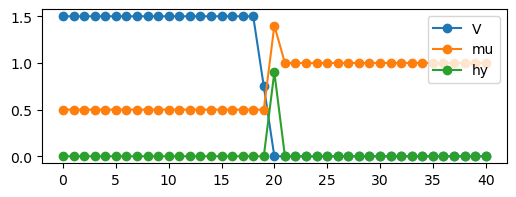

In [35]:
widthS = 20
widthF1 = 1
widthF2 = 20
X, Y = widthS+widthF1+widthF2, 100
lattice = Lattice(X, Y)

t = 1
T = 0.1

muS = 0.5 * t
muF = 1.4 * t
muN = 1.0 * t
mu = np.zeros(lattice.X)
mu[:widthS] = muS
mu[widthS:widthS+widthF1] = muF
mu[widthS+widthF1:] = muN

h0 = 0.9 * t
hy = np.zeros_like(mu)

hy[widthS:widthS+widthF1] = h0

U0 = 5.2 * t
U = U0 * np.ones(lattice.X)
U[widthS:] = 0
U[widthS-1] = U0/2
U=None

V0 = 1.5 * t
V = V0 * np.ones(lattice.X)
V[widthS:] = 0
V[widthS-1] = V0/2

V_prime = None

plt.figure(figsize=(6,2))
if U is not None:
    plt.plot(U, '-o', label="U")
if V is not None:
    plt.plot(V, '-o', label="V")
if V_prime is not None:
    plt.plot(V_prime, '-o', label="V'",)
plt.plot(mu, '-o', label='mu')
plt.plot(hy, '-o', label='hy')

plt.legend()

In [36]:
H = Hamiltonian(t, mu, lattice, U=U, V_prime=V_prime, V=V,
                F_init=[0.1, 0.1, -0.1, -0.1],
                hy=hy)

In [37]:
F_swave, F_dwave, F_px, F_py = bdg_sc(H, atol=1e-4, rtol=0.1, maxiter=100, verbose=True, temperature=T)

F0:
Absolute error: 0.041267409966216355
Relative error: 41267409966.21636
Average old: 0j
Average: (0.0016077681499703255-5.607153682278843e-20j)
F_xplus:
Absolute error: 0.3756206473965626
Relative error: 30767155995.823334
Average old: (0.0475+0j)
Average: (0.08907609927074688+5.301123356914572e-19j)
F_xmin:
Absolute error: 0.38148633213705646
Relative error: 17659115724.713104
Average old: (0.05+0j)
Average: (0.09090092144663012+9.553878368055903e-19j)
F_yplus:
Absolute error: 0.3696386389108323
Relative error: 24696270764.52605
Average old: (-0.04878048780487805+0j)
Average: (-0.08918818241570974+4.272227304174829e-17j)
F_ymin:
Absolute error: 0.3696386389108322
Relative error: 24696270764.526035
Average old: (-0.04878048780487805+0j)
Average: (-0.08918818241570975-4.224355795101654e-17j)
Fuu_xplus:
Absolute error: 0.021320909489937045
Relative error: 21320909489.937046
Average old: 0j
Average: (6.528390617597485e-19-0.0014333164252852179j)
Fuu_xmin:
Absolute error: 0.021320909489

In [38]:
F, Fuu, Fdd = H.get_correlations()


T/t=0.1, hz/t=0.9


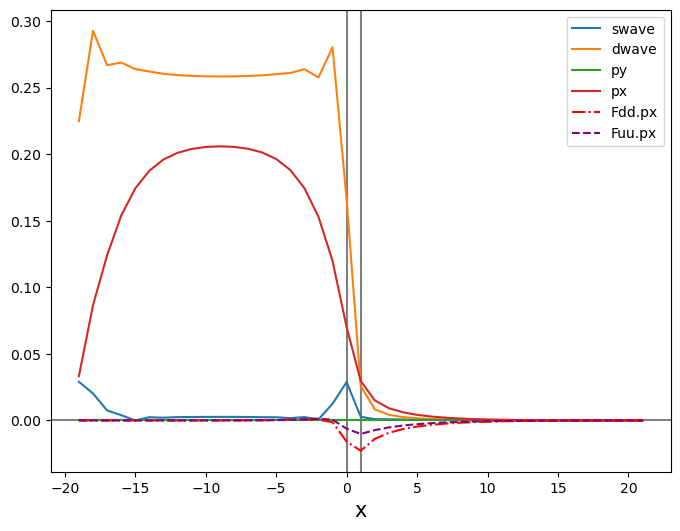

In [39]:
x = np.arange(-widthS, widthF1+widthF2) + 1

fig, axs = plt.subplots(1, 1, figsize=(8, 6))
# axs.set_title(f"T/t={T}, hz/t={h0}")
print(f"T/t={T}, hz/t={h0}")

axs.axhline(0, color='gray')
axs.axvline(0, color='gray')
axs.axvline(widthF1, color='gray')

axs.plot(x, np.abs(F.swave), label=r"swave",)
axs.plot(x, np.abs(F.dwave), label=r"dwave")
axs.plot(x, np.abs(F.py), label=r"py")
axs.plot(x, np.abs(F.px), label=r"px")
axs.plot(x, np.imag(Fdd.px), "-.", label=r"Fdd.px", color='red')
# axs.plot(x, np.imag(Fdd.px), "--", label=r"Fdd", color='green')
axs.plot(x, np.imag(Fuu.px), "--", label=r"Fuu.px", color='purple')

axs.set_xlabel("x", fontsize=15)
plt.legend()
plt.show()